<a href="https://colab.research.google.com/github/Rohil121/bharat-portfolio-lab/blob/v0.4-forecasting-risk-models/notebooks/04_forecasting_risk_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bharat Portfolio Lab v0.4 — Forecasting and Risk Models

## Objective

This notebook develops forecasting and volatility-risk models for Indian
listed equities.

The v0.4 framework will include:

- ARIMA return forecasting
- naive benchmark forecasts
- forecast-confidence intervals
- stationarity and residual diagnostics
- ARCH/GARCH volatility forecasting
- forecast evaluation using a chronological test period
- dynamic volatility forecasts for portfolio allocation

## Research principle

Forecasting models will be evaluated against simple benchmarks rather than
assumed to be useful.

The objective is to quantify uncertainty and forecast risk, not to claim
that tomorrow's stock price can be predicted accurately.

## Dynamic-portfolio requirement

All forecasting functions must accept arbitrary NSE/BSE ticker inputs so
that they can later support user-selected portfolios in the final
application.

In [1]:
%pip install -q yfinance statsmodels arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.0 MB/s eta 0:00:00


In [2]:
# ---------------------------------------------------------
# v0.4 environment setup
# ---------------------------------------------------------

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

from arch import arch_model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf,
)

from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch,
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

DEFAULT_BENCHMARK_TICKER = "^NSEI"
DEFAULT_BENCHMARK_NAME = "Nifty 50"

DEFAULT_FORECAST_TICKERS = [
    "HDFCBANK.NS",
    "TCS.NS",
    "HINDUNILVR.NS",
    "SUNPHARMA.NS",
    "POWERGRID.NS",
    "BHARTIARTL.NS",
    "LT.NS",
    "M&M.NS",
    "BEL.NS",
    "TRENT.NS",
]

FORECAST_DATA_START = "2016-01-01"
FORECAST_TEST_START = pd.Timestamp("2024-01-01")

print("v0.4 forecasting environment prepared.")
print("Default equities:", len(DEFAULT_FORECAST_TICKERS))
print("Forecast test period begins:", FORECAST_TEST_START.date())

v0.4 forecasting environment prepared.
Default equities: 10
Forecast test period begins: 2024-01-01


## 1. Market Data and Chronological Split

Daily adjusted closing prices are downloaded for the selected Indian
equities and benchmark.

Forecasting models will be trained using observations before
1 January 2024 and evaluated only on observations from 1 January 2024
onward.

Daily log returns are used for return forecasting because stock-price
levels are generally non-stationary.

The data function accepts arbitrary ticker lists so it can later support
user-selected portfolios in the Streamlit application.

In [3]:
# ---------------------------------------------------------
# Reusable Indian market-data loader
# ---------------------------------------------------------

def download_adjusted_close_prices(
    tickers,
    benchmark_ticker="^NSEI",
    start_date="2016-01-01",
    end_date=None,
):
    """
    Download adjusted closing prices for an arbitrary list of
    NSE/BSE securities and an Indian market benchmark.
    """

    if not tickers:
        raise ValueError(
            "At least one equity ticker must be supplied."
        )

    cleaned_tickers = [
        str(ticker).strip().upper()
        for ticker in tickers
        if str(ticker).strip()
    ]

    all_tickers = list(
        dict.fromkeys(
            cleaned_tickers
            + [benchmark_ticker]
        )
    )

    if end_date is None:
        end_date = (
            pd.Timestamp.today().normalize()
            + pd.Timedelta(days=1)
        )

    raw_data = yf.download(
        tickers=all_tickers,
        start=str(pd.Timestamp(start_date).date()),
        end=str(pd.Timestamp(end_date).date()),
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if raw_data.empty:
        raise ValueError(
            "No market data was returned."
        )

    # Handle Yahoo Finance's possible column structures
    if isinstance(raw_data.columns, pd.MultiIndex):

        if "Close" in raw_data.columns.get_level_values(0):

            close_prices = (
                raw_data["Close"]
                .copy()
            )

        elif "Close" in raw_data.columns.get_level_values(1):

            close_prices = (
                raw_data
                .xs(
                    "Close",
                    axis=1,
                    level=1,
                )
                .copy()
            )

        else:
            raise ValueError(
                "Closing-price data was not returned."
            )

    else:

        if "Close" not in raw_data.columns:
            raise ValueError(
                "Closing-price data was not returned."
            )

        close_prices = raw_data[["Close"]].copy()

        if len(all_tickers) == 1:
            close_prices.columns = all_tickers

    close_prices = (
        close_prices
        .reindex(columns=all_tickers)
        .sort_index()
        .dropna(how="all")
    )

    missing_tickers = [
        ticker
        for ticker in all_tickers
        if (
            ticker not in close_prices.columns
            or close_prices[ticker].dropna().empty
        )
    ]

    if missing_tickers:
        raise ValueError(
            "No usable price history was found for: "
            + ", ".join(missing_tickers)
        )

    return close_prices

In [4]:
# ---------------------------------------------------------
# Download forecasting dataset
# ---------------------------------------------------------

forecast_price_data = download_adjusted_close_prices(
    tickers=DEFAULT_FORECAST_TICKERS,
    benchmark_ticker=DEFAULT_BENCHMARK_TICKER,
    start_date=FORECAST_DATA_START,
)

forecast_stock_prices = (
    forecast_price_data[
        DEFAULT_FORECAST_TICKERS
    ]
    .copy()
)

forecast_benchmark_prices = (
    forecast_price_data[
        DEFAULT_BENCHMARK_TICKER
    ]
    .rename(DEFAULT_BENCHMARK_NAME)
)

print("Forecasting market data downloaded.")
print("-" * 60)
print(
    "Available period:",
    forecast_price_data.index.min().date(),
    "to",
    forecast_price_data.index.max().date(),
)
print(
    "Securities:",
    len(DEFAULT_FORECAST_TICKERS),
)
print(
    "Benchmark:",
    DEFAULT_BENCHMARK_NAME,
)

Forecasting market data downloaded.
------------------------------------------------------------
Available period: 2016-01-01 to 2026-07-30
Securities: 10
Benchmark: Nifty 50


In [5]:
# ---------------------------------------------------------
# Calculate log returns and chronological split
# ---------------------------------------------------------

forecast_log_returns = (
    np.log(
        forecast_price_data
        / forecast_price_data.shift(1)
    )
)

development_log_returns = (
    forecast_log_returns.loc[
        forecast_log_returns.index
        < FORECAST_TEST_START
    ]
)

test_log_returns = (
    forecast_log_returns.loc[
        forecast_log_returns.index
        >= FORECAST_TEST_START
    ]
)

assert not development_log_returns.empty
assert not test_log_returns.empty
assert (
    development_log_returns.index.max()
    < FORECAST_TEST_START
)
assert (
    test_log_returns.index.min()
    >= FORECAST_TEST_START
)

print("Chronological forecasting split completed.")
print("-" * 60)
print(
    "Development period:",
    development_log_returns.index.min().date(),
    "to",
    development_log_returns.index.max().date(),
)
print(
    "Test period:",
    test_log_returns.index.min().date(),
    "to",
    test_log_returns.index.max().date(),
)

Chronological forecasting split completed.
------------------------------------------------------------
Development period: 2016-01-01 to 2023-12-29
Test period: 2024-01-01 to 2026-07-30


In [6]:
# ---------------------------------------------------------
# Data-quality summary by security
# ---------------------------------------------------------

data_quality_records = []

for ticker in forecast_price_data.columns:

    ticker_prices = (
        forecast_price_data[ticker]
        .dropna()
    )

    ticker_development_returns = (
        development_log_returns[ticker]
        .dropna()
    )

    ticker_test_returns = (
        test_log_returns[ticker]
        .dropna()
    )

    data_quality_records.append(
        {
            "Ticker": ticker,
            "First Price Date":
                ticker_prices.index.min().date(),

            "Latest Price Date":
                ticker_prices.index.max().date(),

            "Price Observations":
                len(ticker_prices),

            "Development Returns":
                len(ticker_development_returns),

            "Test Returns":
                len(ticker_test_returns),

            "Missing Price Values":
                forecast_price_data[ticker]
                .isna()
                .sum(),
        }
    )


forecast_data_quality = (
    pd.DataFrame(data_quality_records)
    .set_index("Ticker")
)

display(forecast_data_quality)

assert (
    forecast_data_quality[
        "Development Returns"
    ] >= 500
).all()

assert (
    forecast_data_quality[
        "Test Returns"
    ] >= 100
).all()

,First Price Date,Latest Price Date,Price Observations,Development Returns,Test Returns,Missing Price Values
Ticker,,,,,,
HDFCBANK.NS,2016-01-01,2026-07-30,2615,1974,640,0
TCS.NS,2016-01-01,2026-07-30,2615,1974,640,0
HINDUNILVR.NS,2016-01-01,2026-07-30,2615,1974,640,0
SUNPHARMA.NS,2016-01-01,2026-07-30,2615,1974,640,0
POWERGRID.NS,2016-01-01,2026-07-30,2615,1974,640,0
BHARTIARTL.NS,2016-01-01,2026-07-30,2615,1974,640,0
LT.NS,2016-01-01,2026-07-30,2615,1974,640,0
M&M.NS,2016-01-01,2026-07-30,2615,1974,640,0
BEL.NS,2016-01-01,2026-07-30,2615,1974,640,0


## 2. Return-Series Stationarity Diagnostics

ARIMA models require the modelled time series to be reasonably
stationary.

A stationary series has statistical properties such as its mean and
variance that remain broadly stable through time.

Daily stock-price levels are usually non-stationary. Daily log returns
are generally more suitable for ARIMA modelling.

The Augmented Dickey–Fuller test is applied only to development-period
returns.

### Hypotheses

- **Null hypothesis:** the series contains a unit root and is non-stationary
- **Alternative hypothesis:** the series is stationary

A p-value below 5% leads to rejection of the null hypothesis.

In [7]:
# ---------------------------------------------------------
# Reusable Augmented Dickey–Fuller diagnostic
# ---------------------------------------------------------

def run_adf_stationarity_test(
    time_series,
    significance_level=0.05,
):
    """
    Run the Augmented Dickey–Fuller stationarity test
    on one return series.
    """

    clean_series = (
        pd.Series(time_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_series) < 100:
        raise ValueError(
            "At least 100 observations are required "
            "for the stationarity test."
        )

    adf_result = adfuller(
        clean_series,
        autolag="AIC",
    )

    adf_statistic = adf_result[0]
    p_value = adf_result[1]
    selected_lags = adf_result[2]
    observations = adf_result[3]
    critical_values = adf_result[4]

    is_stationary = (
        p_value < significance_level
    )

    return {
        "ADF Statistic": adf_statistic,
        "P-Value": p_value,
        "Selected Lags": selected_lags,
        "Observations": observations,
        "1% Critical Value": critical_values["1%"],
        "5% Critical Value": critical_values["5%"],
        "10% Critical Value": critical_values["10%"],
        "Stationary at 5%": is_stationary,
    }

In [8]:
# ---------------------------------------------------------
# Development-period stationarity testing
# ---------------------------------------------------------

stationarity_records = []

for ticker in development_log_returns.columns:

    ticker_result = run_adf_stationarity_test(
        development_log_returns[ticker]
    )

    stationarity_records.append(
        {
            "Ticker": ticker,
            **ticker_result,
        }
    )

stationarity_results = (
    pd.DataFrame(stationarity_records)
    .set_index("Ticker")
)

print("Development-Period ADF Stationarity Results")
display(
    stationarity_results.style.format(
        {
            "ADF Statistic": "{:.4f}",
            "P-Value": "{:.6f}",
            "1% Critical Value": "{:.4f}",
            "5% Critical Value": "{:.4f}",
            "10% Critical Value": "{:.4f}",
        }
    )
)

Development-Period ADF Stationarity Results


,ADF Statistic,P-Value,Selected Lags,Observations,1% Critical Value,5% Critical Value,10% Critical Value,Stationary at 5%
Ticker,,,,,,,,
HDFCBANK.NS,-9.9991,0.000000,21,1952,-3.4337,-2.8630,-2.5676,True
TCS.NS,-45.1341,0.000000,0,1973,-3.4337,-2.8630,-2.5676,True
HINDUNILVR.NS,-15.9853,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True
SUNPHARMA.NS,-44.8964,0.000000,0,1973,-3.4337,-2.8630,-2.5676,True
POWERGRID.NS,-19.3835,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True
BHARTIARTL.NS,-33.2717,0.000000,1,1972,-3.4337,-2.8630,-2.5676,True
LT.NS,-14.2411,0.000000,8,1965,-3.4337,-2.8630,-2.5676,True
M&M.NS,-17.1088,0.000000,5,1968,-3.4337,-2.8630,-2.5676,True
BEL.NS,-16.3297,0.000000,6,1967,-3.4337,-2.8630,-2.5676,True


In [9]:
stationary_series_count = int(
    stationarity_results[
        "Stationary at 5%"
    ].sum()
)

total_series_count = len(
    stationarity_results
)

stationarity_summary = pd.DataFrame(
    {
        "Result": [
            total_series_count,
            stationary_series_count,
            total_series_count
            - stationary_series_count,
            stationary_series_count
            / total_series_count,
        ],
    },
    index=[
        "Series Tested",
        "Stationary at 5%",
        "Non-Stationary at 5%",
        "Stationary Percentage",
    ],
)

formatted_stationarity_summary = (
    stationarity_summary
    .copy()
    .astype(object)
)

formatted_stationarity_summary.loc[
    "Stationary Percentage",
    "Result",
] = (
    f"{stationary_series_count / total_series_count:.2%}"
)

print("Stationarity Summary")
display(formatted_stationarity_summary)

Stationarity Summary


,Result
Series Tested,11.0
Stationary at 5%,11.0
Non-Stationary at 5%,0.0
Stationary Percentage,100.00%


## 3. ARIMA Order Selection

Because all development-period log-return series passed the stationarity
test, the integration order is fixed at zero.

Candidate ARIMA(p, 0, q) models are compared using only development-period
data.

The preferred order is selected using the Bayesian Information Criterion
(BIC). BIC rewards goodness of fit but penalises unnecessary model
complexity more strongly than AIC.

No observations from the out-of-sample test period are used during model
selection.

In [10]:
# ---------------------------------------------------------
# Reusable ARIMA order-selection function
# ---------------------------------------------------------

def select_arima_order(
    time_series,
    p_values=range(0, 4),
    q_values=range(0, 4),
    selection_criterion="BIC",
):
    """
    Compare ARIMA(p, 0, q) models using development data only.

    Returns:
        selected_order
        ranked_results
        fitted_models
    """

    clean_series = (
        pd.Series(time_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(clean_series) < 500:
        raise ValueError(
            "At least 500 observations are required "
            "for ARIMA order selection."
        )

    # Percentage scaling improves numerical optimisation.
    scaled_series = clean_series * 100

    selection_records = []
    fitted_models = {}

    for p_value in p_values:

        for q_value in q_values:

            model_order = (
                int(p_value),
                0,
                int(q_value),
            )

            try:

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore"
                    )

                    fitted_model = ARIMA(
                        scaled_series,
                        order=model_order,
                        trend="c",
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit()

                converged = bool(
                    fitted_model.mle_retvals.get(
                        "converged",
                        True,
                    )
                )

                selection_records.append(
                    {
                        "Order": model_order,
                        "p": p_value,
                        "d": 0,
                        "q": q_value,
                        "AIC": fitted_model.aic,
                        "BIC": fitted_model.bic,
                        "HQIC": fitted_model.hqic,
                        "Log Likelihood": fitted_model.llf,
                        "Parameters": len(
                            fitted_model.params
                        ),
                        "Converged": converged,
                    }
                )

                fitted_models[
                    model_order
                ] = fitted_model

            except Exception as error:

                selection_records.append(
                    {
                        "Order": model_order,
                        "p": p_value,
                        "d": 0,
                        "q": q_value,
                        "AIC": np.nan,
                        "BIC": np.nan,
                        "HQIC": np.nan,
                        "Log Likelihood": np.nan,
                        "Parameters": np.nan,
                        "Converged": False,
                        "Error": str(error),
                    }
                )

    order_results = pd.DataFrame(
        selection_records
    )

    criterion_column = (
        selection_criterion
        .strip()
        .upper()
    )

    allowed_criteria = {
        "AIC",
        "BIC",
        "HQIC",
    }

    if criterion_column not in allowed_criteria:
        raise ValueError(
            "Selection criterion must be AIC, BIC or HQIC."
        )

    valid_results = (
        order_results.loc[
            order_results["Converged"]
            & order_results[
                criterion_column
            ].notna()
        ]
        .sort_values(
            criterion_column,
            ascending=True,
        )
        .reset_index(drop=True)
    )

    if valid_results.empty:
        raise RuntimeError(
            "No ARIMA candidate converged successfully."
        )

    selected_order = tuple(
        valid_results.loc[
            0,
            ["p", "d", "q"],
        ].astype(int)
    )

    return {
        "Selected Order": selected_order,
        "Ranked Results": valid_results,
        "All Results": order_results,
        "Fitted Models": fitted_models,
        "Selection Criterion": criterion_column,
    }

In [11]:
# ---------------------------------------------------------
# Nifty 50 development-period ARIMA selection
# ---------------------------------------------------------

benchmark_arima_selection = select_arima_order(
    time_series=development_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ],
    p_values=range(0, 4),
    q_values=range(0, 4),
    selection_criterion="BIC",
)

benchmark_arima_order = (
    benchmark_arima_selection[
        "Selected Order"
    ]
)

benchmark_arima_ranking = (
    benchmark_arima_selection[
        "Ranked Results"
    ]
)

print("Nifty 50 ARIMA Order Selection")
print("-" * 60)
print(
    "Selected order:",
    benchmark_arima_order,
)
print(
    "Selection criterion:",
    benchmark_arima_selection[
        "Selection Criterion"
    ],
)
print(
    "Successful candidate models:",
    len(benchmark_arima_ranking),
)

display(
    benchmark_arima_ranking[
        [
            "Order",
            "AIC",
            "BIC",
            "HQIC",
            "Log Likelihood",
            "Parameters",
        ]
    ]
    .head(10)
    .style.format(
        {
            "AIC": "{:.2f}",
            "BIC": "{:.2f}",
            "HQIC": "{:.2f}",
            "Log Likelihood": "{:.2f}",
            "Parameters": "{:.0f}",
        }
    )
)

Nifty 50 ARIMA Order Selection
------------------------------------------------------------
Selected order: (2, 0, 3)
Selection criterion: BIC
Successful candidate models: 15


,Order,AIC,BIC,HQIC,Log Likelihood,Parameters
0,"(2, 0, 3)",5799.69,5838.75,5814.05,-2892.84,7
1,"(3, 0, 3)",5802.79,5847.43,5819.20,-2893.40,8
2,"(0, 0, 0)",5856.33,5867.49,5860.43,-2926.16,2
3,"(0, 0, 1)",5854.66,5871.40,5860.81,-2924.33,3
4,"(0, 0, 2)",5849.35,5871.67,5857.55,-2920.67,4
5,"(1, 0, 3)",5839.20,5872.68,5851.51,-2913.60,6
6,"(1, 0, 0)",5856.98,5873.73,5863.14,-2925.49,3
7,"(3, 0, 1)",5840.92,5874.41,5853.23,-2914.46,6
8,"(0, 0, 3)",5848.83,5876.73,5859.09,-2919.42,5
9,"(1, 0, 1)",5855.89,5878.21,5864.09,-2923.94,4


## 4. ARIMA Residual Diagnostics

A fitted ARIMA model should leave residuals that resemble unpredictable
noise.

The following development-period diagnostics are applied:

- **Ljung–Box test:** checks whether residual autocorrelation remains
- **ARCH LM test:** checks whether residual volatility clustering remains
- **Jarque–Bera test:** checks whether residuals are normally distributed

### Interpretation

For the Ljung–Box test, a p-value above 5% suggests that the ARIMA model
has adequately captured linear return dependence.

For the ARCH LM test, a p-value below 5% indicates remaining volatility
clustering and supports the later use of an ARCH/GARCH model.

For the Jarque–Bera test, a p-value below 5% indicates non-normal residuals,
such as skewness or fat tails.

In [12]:
# ---------------------------------------------------------
# Retrieve the selected development-period ARIMA model
# ---------------------------------------------------------

from scipy.stats import (
    jarque_bera,
    kurtosis,
    skew,
)

benchmark_arima_model = (
    benchmark_arima_selection[
        "Fitted Models"
    ][benchmark_arima_order]
)

benchmark_arima_residuals = (
    pd.Series(
        benchmark_arima_model.resid
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

selected_p = benchmark_arima_order[0]
selected_q = benchmark_arima_order[2]

print("Selected ARIMA order:", benchmark_arima_order)
print(
    "Residual observations:",
    f"{len(benchmark_arima_residuals):,}",
)
print(
    "Residual mean:",
    f"{benchmark_arima_residuals.mean():.6f}",
)
print(
    "Residual standard deviation:",
    f"{benchmark_arima_residuals.std(ddof=1):.6f}",
)

Selected ARIMA order: (2, 0, 3)
Residual observations: 1,963
Residual mean: -0.003903
Residual standard deviation: 1.065262


In [13]:
# ---------------------------------------------------------
# Ljung–Box residual-autocorrelation tests
# ---------------------------------------------------------

ljung_box_results = acorr_ljungbox(
    benchmark_arima_residuals,
    lags=[10, 20],
    model_df=selected_p + selected_q,
    return_df=True,
)


# ---------------------------------------------------------
# ARCH LM volatility-clustering test
# ---------------------------------------------------------

(
    arch_lm_statistic,
    arch_lm_p_value,
    arch_f_statistic,
    arch_f_p_value,
) = het_arch(
    benchmark_arima_residuals,
    nlags=10,
)


# ---------------------------------------------------------
# Jarque–Bera residual-normality test
# ---------------------------------------------------------

jarque_bera_result = jarque_bera(
    benchmark_arima_residuals
)

jarque_bera_statistic = (
    jarque_bera_result.statistic
)

jarque_bera_p_value = (
    jarque_bera_result.pvalue
)


# ---------------------------------------------------------
# Combine diagnostic results
# ---------------------------------------------------------

arima_diagnostic_results = pd.DataFrame(
    {
        "Test Statistic": [
            ljung_box_results.loc[
                10,
                "lb_stat",
            ],
            ljung_box_results.loc[
                20,
                "lb_stat",
            ],
            arch_lm_statistic,
            jarque_bera_statistic,
        ],
        "P-Value": [
            ljung_box_results.loc[
                10,
                "lb_pvalue",
            ],
            ljung_box_results.loc[
                20,
                "lb_pvalue",
            ],
            arch_lm_p_value,
            jarque_bera_p_value,
        ],
    },
    index=[
        "Ljung–Box Residual Autocorrelation — 10 Lags",
        "Ljung–Box Residual Autocorrelation — 20 Lags",
        "ARCH LM Volatility Clustering — 10 Lags",
        "Jarque–Bera Residual Normality",
    ],
)

arima_diagnostic_results[
    "Result at 5%"
] = [
    (
        "No significant residual autocorrelation"
        if ljung_box_results.loc[10, "lb_pvalue"] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "No significant residual autocorrelation"
        if ljung_box_results.loc[20, "lb_pvalue"] >= 0.05
        else "Residual autocorrelation remains"
    ),
    (
        "ARCH effects remain"
        if arch_lm_p_value < 0.05
        else "No significant ARCH effects"
    ),
    (
        "Residuals are non-normal"
        if jarque_bera_p_value < 0.05
        else "Normality not rejected"
    ),
]

print("Nifty 50 ARIMA Residual Diagnostics")

display(
    arima_diagnostic_results.style.format(
        {
            "Test Statistic": "{:.4f}",
            "P-Value": "{:.6f}",
        }
    )
)

print("\nResidual distribution statistics")
print("-" * 55)
print(
    "Skewness:",
    f"{skew(benchmark_arima_residuals):.4f}",
)
print(
    "Excess kurtosis:",
    f"{kurtosis(benchmark_arima_residuals):.4f}",
)

Nifty 50 ARIMA Residual Diagnostics


,Test Statistic,P-Value,Result at 5%
Ljung–Box Residual Autocorrelation — 10 Lags,18.8888,0.002016,Residual autocorrelation remains
Ljung–Box Residual Autocorrelation — 20 Lags,23.3407,0.077169,No significant residual autocorrelation
ARCH LM Volatility Clustering — 10 Lags,579.1630,0.000000,ARCH effects remain
Jarque–Bera Residual Normality,25942.2475,0.000000,Residuals are non-normal



Residual distribution statistics
-------------------------------------------------------
Skewness: -1.1442
Excess kurtosis: 17.6618


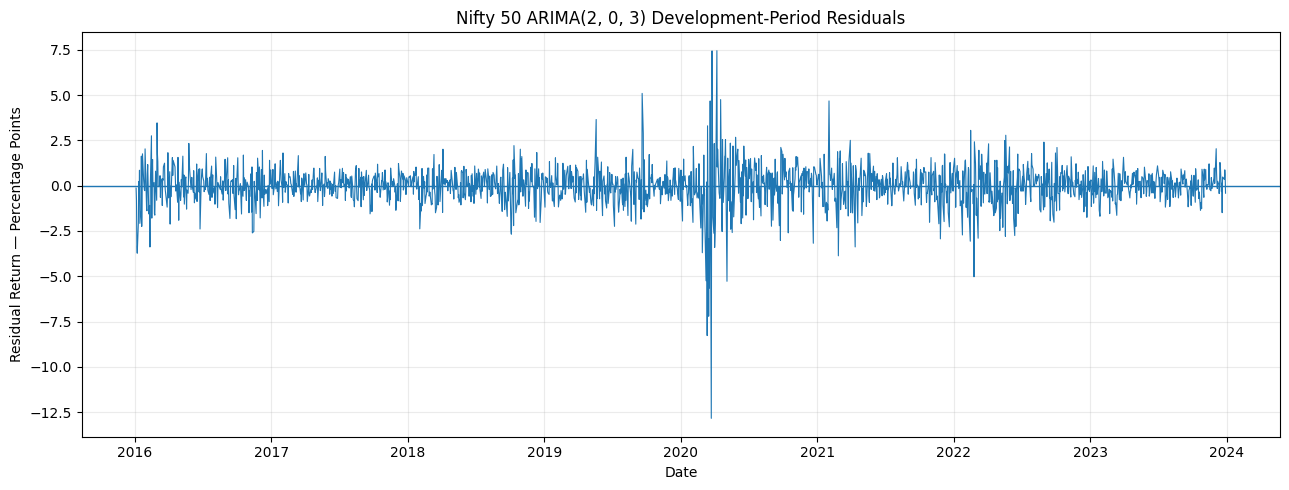

In [14]:
plt.figure(figsize=(13, 5))

plt.plot(
    benchmark_arima_residuals.index,
    benchmark_arima_residuals,
    linewidth=0.8,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.title(
    "Nifty 50 ARIMA(2, 0, 3) Development-Period Residuals"
)
plt.xlabel("Date")
plt.ylabel("Residual Return — Percentage Points")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

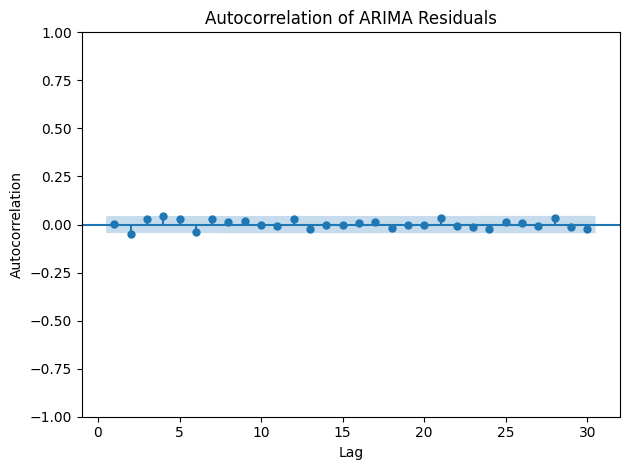

In [15]:
plot_acf(
    benchmark_arima_residuals,
    lags=30,
    zero=False,
)

plt.title(
    "Autocorrelation of ARIMA Residuals"
)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

## 5. ARIMA Diagnostic Interpretation

The selected ARIMA(2, 0, 3) model does not fully explain Nifty 50
daily log-return behaviour.

### Residual autocorrelation

The Ljung–Box test at 10 lags produced a p-value of 0.0020.

The null hypothesis of no residual autocorrelation is therefore rejected
at the 5% significance level. Some short-horizon linear dependence remains
after fitting the ARIMA model.

At 20 lags, the Ljung–Box p-value was 0.0772. The null hypothesis is not
rejected at the 5% level, suggesting that residual autocorrelation is less
evident across the broader lag window.

The mixed result means that the ARIMA model captures part, but not all, of
the return-series dependence.

### Volatility clustering

The ARCH LM test produced a p-value below 0.001.

Strong conditional heteroskedasticity therefore remains in the ARIMA
residuals. Large residual movements tend to be followed by further large
movements, while quiet observations tend to cluster together.

This provides statistical justification for modelling residual volatility
using an ARCH or GARCH framework.

### Residual distribution

The Jarque–Bera test rejected residual normality with a p-value below
0.001.

The residual distribution therefore contains material departures from
normality, such as asymmetry, fat tails or extreme observations.

Normal-distribution forecast intervals may consequently understate the
probability of large market movements.

### Research conclusion

ARIMA(2, 0, 3) should be treated as a candidate conditional-mean model,
not as a complete return-generating model.

Its forecasting value must still be tested against simple naive
benchmarks during the out-of-sample period.

The remaining volatility clustering supports combining the mean model
with GARCH volatility forecasts. A heavy-tailed innovation distribution,
such as the Student's t distribution, should also be considered.

## 6. Out-of-Sample ARIMA Forecast Evaluation

The selected ARIMA(2, 0, 3) model is evaluated using sequential
one-trading-day-ahead forecasts during the test period.

For each test observation:

1. A forecast is generated using only information available before that day.
2. The actual return is then revealed.
3. The observation is added to the model history without refitting the
   model parameters.

The ARIMA forecasts are compared with three simple benchmarks:

- zero-return forecast,
- previous-day return forecast, and
- expanding historical-mean forecast.

A complex model should not be considered useful merely because it fits
historical data. It must improve meaningfully on these naive alternatives.

In [16]:
# ---------------------------------------------------------
# Sequential one-step-ahead forecasts
# ---------------------------------------------------------

benchmark_test_returns = (
    test_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

benchmark_development_returns = (
    development_log_returns[
        DEFAULT_BENCHMARK_TICKER
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

recursive_arima_model = (
    benchmark_arima_model
)

return_history = (
    benchmark_development_returns
    .copy()
)

forecast_records = []

for forecast_date, actual_return in (
    benchmark_test_returns.items()
):

    # Forecast is in percentage-point units because
    # the ARIMA model was fitted to returns multiplied by 100.
    forecast_result = (
        recursive_arima_model
        .get_forecast(steps=1)
    )

    arima_forecast_percentage = float(
        np.asarray(
            forecast_result.predicted_mean
        ).reshape(-1)[0]
    )

    confidence_interval = np.asarray(
        forecast_result.conf_int(
            alpha=0.05
        )
    ).reshape(-1, 2)[0]

    lower_forecast_percentage = float(
        confidence_interval[0]
    )

    upper_forecast_percentage = float(
        confidence_interval[1]
    )

    previous_day_forecast = float(
        return_history.iloc[-1]
    )

    expanding_mean_forecast = float(
        return_history.mean()
    )

    forecast_records.append(
        {
            "Date": forecast_date,
            "Actual Return": actual_return,
            "ARIMA Forecast":
                arima_forecast_percentage / 100,
            "ARIMA Lower 95%":
                lower_forecast_percentage / 100,
            "ARIMA Upper 95%":
                upper_forecast_percentage / 100,
            "Zero-Return Forecast": 0.0,
            "Previous-Day Forecast":
                previous_day_forecast,
            "Expanding-Mean Forecast":
                expanding_mean_forecast,
        }
    )

    # Reveal the actual observation only after forecasting.
    recursive_arima_model = (
        recursive_arima_model.append(
            [actual_return * 100],
            refit=False,
        )
    )

    return_history.loc[
        forecast_date
    ] = actual_return


benchmark_forecasts = (
    pd.DataFrame(forecast_records)
    .set_index("Date")
    .sort_index()
)

assert len(benchmark_forecasts) == len(
    benchmark_test_returns
)

assert benchmark_forecasts.isna().sum().sum() == 0

print("Sequential ARIMA forecasts completed.")
print("-" * 60)
print(
    "Forecast period:",
    benchmark_forecasts.index.min().date(),
    "to",
    benchmark_forecasts.index.max().date(),
)
print(
    "One-step forecasts:",
    f"{len(benchmark_forecasts):,}",
)

display(benchmark_forecasts.head())

Sequential ARIMA forecasts completed.
------------------------------------------------------------
Forecast period: 2024-01-01 to 2026-07-30
One-step forecasts: 632


,Actual Return,ARIMA Forecast,ARIMA Lower 95%,ARIMA Upper 95%,Zero-Return Forecast,Previous-Day Forecast,Expanding-Mean Forecast
Date,,,,,,,
2024-01-01,0.000483,0.000038,-0.020710,0.020785,0.0,-0.002174,0.000512
2024-01-02,-0.003506,0.000090,-0.020658,0.020838,0.0,0.000483,0.000512
2024-01-03,-0.006875,0.001272,-0.019476,0.022020,0.0,-0.003506,0.000510
2024-01-04,0.006543,-0.000547,-0.021295,0.020201,0.0,-0.006875,0.000506
2024-01-05,0.002407,0.000613,-0.020134,0.021361,0.0,0.006543,0.000509


In [17]:
# ---------------------------------------------------------
# Reusable forecast-evaluation function
# ---------------------------------------------------------

def calculate_forecast_accuracy(
    actual_returns,
    forecast_returns,
):
    """
    Calculate standard point-forecast accuracy statistics.
    """

    evaluation_data = pd.concat(
        [
            pd.Series(
                actual_returns,
                name="Actual",
            ),
            pd.Series(
                forecast_returns,
                name="Forecast",
            ),
        ],
        axis=1,
    ).dropna()

    errors = (
        evaluation_data["Forecast"]
        - evaluation_data["Actual"]
    )

    mae = mean_absolute_error(
        evaluation_data["Actual"],
        evaluation_data["Forecast"],
    )

    rmse = np.sqrt(
        mean_squared_error(
            evaluation_data["Actual"],
            evaluation_data["Forecast"],
        )
    )

    directional_accuracy = (
        np.sign(
            evaluation_data["Forecast"]
        )
        == np.sign(
            evaluation_data["Actual"]
        )
    ).mean()

    return {
        "Observations": len(evaluation_data),
        "MAE": mae,
        "RMSE": rmse,
        "Forecast Bias": errors.mean(),
        "Directional Accuracy":
            directional_accuracy,
        "Forecast–Actual Correlation":
            evaluation_data[
                "Forecast"
            ].corr(
                evaluation_data["Actual"]
            ),
    }


forecast_model_columns = {
    "ARIMA(2, 0, 3)":
        "ARIMA Forecast",

    "Zero-Return Benchmark":
        "Zero-Return Forecast",

    "Previous-Day Benchmark":
        "Previous-Day Forecast",

    "Expanding-Mean Benchmark":
        "Expanding-Mean Forecast",
}

forecast_accuracy_records = []

for model_name, forecast_column in (
    forecast_model_columns.items()
):

    model_metrics = (
        calculate_forecast_accuracy(
            actual_returns=
                benchmark_forecasts[
                    "Actual Return"
                ],
            forecast_returns=
                benchmark_forecasts[
                    forecast_column
                ],
        )
    )

    forecast_accuracy_records.append(
        {
            "Forecast Model": model_name,
            **model_metrics,
        }
    )


forecast_accuracy_results = (
    pd.DataFrame(
        forecast_accuracy_records
    )
    .set_index("Forecast Model")
    .sort_values("RMSE")
)

zero_benchmark_rmse = (
    forecast_accuracy_results.loc[
        "Zero-Return Benchmark",
        "RMSE",
    ]
)

forecast_accuracy_results[
    "RMSE Improvement vs Zero"
] = (
    1
    - forecast_accuracy_results["RMSE"]
    / zero_benchmark_rmse
)

print("Out-of-Sample Forecast Accuracy")

display(
    forecast_accuracy_results.style.format(
        {
            "Observations": "{:,.0f}",
            "MAE": "{:.4%}",
            "RMSE": "{:.4%}",
            "Forecast Bias": "{:+.4%}",
            "Directional Accuracy": "{:.2%}",
            "Forecast–Actual Correlation": "{:.4f}",
            "RMSE Improvement vs Zero": "{:+.2%}",
        }
    )
)

Out-of-Sample Forecast Accuracy


,Observations,MAE,RMSE,Forecast Bias,Directional Accuracy,Forecast–Actual Correlation,RMSE Improvement vs Zero
Forecast Model,,,,,,,
Zero-Return Benchmark,632,0.6160%,0.8648%,-0.0199%,0.16%,nan,+0.00%
Expanding-Mean Benchmark,632,0.6158%,0.8652%,+0.0289%,52.22%,-0.0413,-0.05%
"ARIMA(2, 0, 3)",632,0.6308%,0.8780%,+0.0300%,49.05%,-0.0301,-1.52%
Previous-Day Benchmark,632,0.8907%,1.2780%,-0.0008%,52.37%,-0.0925,-47.78%


In [18]:
# ---------------------------------------------------------
# Forecast-interval coverage
# ---------------------------------------------------------

arima_interval_coverage = (
    (
        benchmark_forecasts[
            "Actual Return"
        ]
        >= benchmark_forecasts[
            "ARIMA Lower 95%"
        ]
    )
    & (
        benchmark_forecasts[
            "Actual Return"
        ]
        <= benchmark_forecasts[
            "ARIMA Upper 95%"
        ]
    )
).mean()

average_interval_width = (
    benchmark_forecasts[
        "ARIMA Upper 95%"
    ]
    - benchmark_forecasts[
        "ARIMA Lower 95%"
    ]
).mean()

arima_interval_summary = pd.DataFrame(
    {
        "Result": [
            arima_interval_coverage,
            average_interval_width,
            0.95,
        ],
    },
    index=[
        "Observed 95% Interval Coverage",
        "Average 95% Interval Width",
        "Target Interval Coverage",
    ],
)

formatted_interval_summary = (
    arima_interval_summary
    .copy()
    .astype(object)
)

for metric in formatted_interval_summary.index:

    formatted_interval_summary.loc[
        metric,
        "Result",
    ] = (
        f"{arima_interval_summary.loc[metric, 'Result']:.2%}"
    )

print("ARIMA Forecast-Interval Summary")
display(formatted_interval_summary)

ARIMA Forecast-Interval Summary


,Result
Observed 95% Interval Coverage,97.63%
Average 95% Interval Width,4.15%
Target Interval Coverage,95.00%


## 7. ARCH and GARCH Model Selection

The ARIMA residual diagnostics revealed strong volatility clustering and
non-normality.

ARCH-family models are therefore fitted to the development-period ARIMA
residuals.

The candidate set includes:

- ARCH(1) with normal innovations
- ARCH(1) with Student's t innovations
- GARCH(1,1) with normal innovations
- GARCH(1,1) with Student's t innovations
- GJR-GARCH(1,1) with normal innovations
- GJR-GARCH(1,1) with Student's t innovations

The GJR-GARCH specification allows negative and positive shocks to have
different effects on future volatility.

Student's t innovations allow for heavier tails than the normal
distribution.

Models are ranked using BIC and only development-period residuals are used.

In [19]:
# ---------------------------------------------------------
# Prepare development-period ARIMA residuals
# ---------------------------------------------------------

arima_residual_burn_in = max(
    benchmark_arima_order[0],
    benchmark_arima_order[2],
    1,
)

garch_development_residuals = (
    benchmark_arima_residuals
    .iloc[arima_residual_burn_in:]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .astype(float)
)

print("GARCH development residuals prepared.")
print("-" * 60)
print(
    "Observations:",
    f"{len(garch_development_residuals):,}",
)
print(
    "Units:",
    "daily return percentage points",
)

GARCH development residuals prepared.
------------------------------------------------------------
Observations: 1,960
Units: daily return percentage points


In [20]:
# ---------------------------------------------------------
# ARCH/GARCH candidate specifications
# ---------------------------------------------------------

volatility_candidate_specs = {
    "ARCH(1) — Normal": {
        "vol": "ARCH",
        "p": 1,
        "o": 0,
        "q": 0,
        "dist": "normal",
    },
    "ARCH(1) — Student's t": {
        "vol": "ARCH",
        "p": 1,
        "o": 0,
        "q": 0,
        "dist": "t",
    },
    "GARCH(1,1) — Normal": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "normal",
    },
    "GARCH(1,1) — Student's t": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "dist": "t",
    },
    "GJR-GARCH(1,1) — Normal": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "normal",
    },
    "GJR-GARCH(1,1) — Student's t": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "dist": "t",
    },
}

In [21]:
# ---------------------------------------------------------
# Fit and compare volatility models
# ---------------------------------------------------------

volatility_selection_records = []
fitted_volatility_models = {}

for model_name, model_spec in (
    volatility_candidate_specs.items()
):

    try:

        with warnings.catch_warnings():

            warnings.simplefilter("ignore")

            candidate_model = arch_model(
                garch_development_residuals,
                mean="Zero",
                vol=model_spec["vol"],
                p=model_spec["p"],
                o=model_spec["o"],
                q=model_spec["q"],
                dist=model_spec["dist"],
                rescale=False,
            )

            fitted_model = candidate_model.fit(
                disp="off",
            )

        converged = (
            fitted_model.convergence_flag == 0
        )

        model_parameters = fitted_model.params

        alpha_value = float(
            model_parameters.get(
                "alpha[1]",
                0.0,
            )
        )

        beta_value = float(
            model_parameters.get(
                "beta[1]",
                0.0,
            )
        )

        gamma_value = float(
            model_parameters.get(
                "gamma[1]",
                0.0,
            )
        )

        # Under a symmetric innovation distribution, the
        # GJR persistence approximation includes half gamma.
        persistence = (
            alpha_value
            + beta_value
            + 0.5 * gamma_value
        )

        volatility_selection_records.append(
            {
                "Model": model_name,
                "AIC": fitted_model.aic,
                "BIC": fitted_model.bic,
                "Log Likelihood":
                    fitted_model.loglikelihood,
                "Parameters":
                    len(fitted_model.params),
                "Alpha": alpha_value,
                "Beta": beta_value,
                "Gamma": gamma_value,
                "Persistence": persistence,
                "Degrees of Freedom":
                    float(
                        model_parameters.get(
                            "nu",
                            np.nan,
                        )
                    ),
                "Converged": converged,
            }
        )

        fitted_volatility_models[
            model_name
        ] = fitted_model

    except Exception as error:

        volatility_selection_records.append(
            {
                "Model": model_name,
                "AIC": np.nan,
                "BIC": np.nan,
                "Log Likelihood": np.nan,
                "Parameters": np.nan,
                "Alpha": np.nan,
                "Beta": np.nan,
                "Gamma": np.nan,
                "Persistence": np.nan,
                "Degrees of Freedom": np.nan,
                "Converged": False,
                "Error": str(error),
            }
        )


volatility_model_comparison = (
    pd.DataFrame(
        volatility_selection_records
    )
    .set_index("Model")
)

valid_volatility_models = (
    volatility_model_comparison.loc[
        volatility_model_comparison[
            "Converged"
        ]
        & volatility_model_comparison[
            "BIC"
        ].notna()
    ]
    .sort_values("BIC")
)

if valid_volatility_models.empty:
    raise RuntimeError(
        "No ARCH/GARCH candidate converged."
    )

selected_volatility_model_name = (
    valid_volatility_models.index[0]
)

selected_volatility_model = (
    fitted_volatility_models[
        selected_volatility_model_name
    ]
)

print("ARCH/GARCH Model Selection")
print("-" * 60)
print(
    "Selected model:",
    selected_volatility_model_name,
)
print(
    "Selection criterion: BIC"
)

display(
    valid_volatility_models.style.format(
        {
            "AIC": "{:.2f}",
            "BIC": "{:.2f}",
            "Log Likelihood": "{:.2f}",
            "Parameters": "{:.0f}",
            "Alpha": "{:.4f}",
            "Beta": "{:.4f}",
            "Gamma": "{:.4f}",
            "Persistence": "{:.4f}",
            "Degrees of Freedom": "{:.2f}",
        },
        na_rep="—",
    )
)

ARCH/GARCH Model Selection
------------------------------------------------------------
Selected model: GJR-GARCH(1,1) — Student's t
Selection criterion: BIC


,AIC,BIC,Log Likelihood,Parameters,Alpha,Beta,Gamma,Persistence,Degrees of Freedom,Converged
Model,,,,,,,,,,
"GJR-GARCH(1,1) — Student's t",4930.27,4958.17,-2460.14,5,0.0000,0.8950,0.1458,0.9679,9.56,True
"GJR-GARCH(1,1) — Normal",4973.02,4995.35,-2482.51,4,0.0000,0.8912,0.1516,0.9670,—,True
"GARCH(1,1) — Student's t",4990.04,5012.36,-2491.02,4,0.0786,0.8986,0.0000,0.9771,8.25,True
"GARCH(1,1) — Normal",5046.28,5063.02,-2520.14,3,0.0946,0.8869,0.0000,0.9816,—,True
ARCH(1) — Student's t,5175.97,5192.72,-2584.99,3,0.3481,0.0000,0.0000,0.3481,4.62,True
ARCH(1) — Normal,5442.58,5453.74,-2719.29,2,0.4056,0.0000,0.0000,0.4056,—,True
